# ==========================================================
# Imports
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.optimize import linprog
from scipy.sparse import lil_matrix, csr_matrix

In [1]:
# ==========================================================
# Imports
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.optimize import linprog
from scipy.sparse import lil_matrix, csr_matrix
print("Imports successful!")

Imports successful!


In [2]:
# ==========================================================
# Load yearly datasets
# ==========================================================

ev = pd.read_csv("../data/raw/ev_sessions.csv")

load_mat = loadmat("../data/raw/load_yearly.mat")
pv_mat = loadmat("../data/raw/PV_production_yearly.mat")
price_mat = loadmat("../data/raw/prices_yearly.mat")

load_year = load_mat["load_all_year"].flatten()
pv_factor = pv_mat["zeta_PV"].flatten()
price_year = price_mat["prices_all_year"].flatten()

print("EV sessions:", len(ev))
print("Load shape:", load_year.shape)
print("PV shape:", pv_factor.shape)
print("Price shape:", price_year.shape)

EV sessions: 8530
Load shape: (8760,)
PV shape: (8760,)
Price shape: (8760,)


In [3]:
# ==========================================================
# Optimally sized PV+BESS system from Notebook 13
# ==========================================================
#
# These values come from the OSOPSS-style joint sizing LP.
# They replace the manually guessed sizes used earlier.
# ==========================================================

S_PV_opt = 588.77        # [kWp]
E_BESS_opt = 403.43      # [kWh]
P_BESS_opt = 103.25      # [kW]

SOC_min = (1 - 0.85) * E_BESS_opt
SOC_max = E_BESS_opt

SOC_initial = 0.5 * E_BESS_opt

eta_ch = 0.9
eta_dch = 0.9

print("PV size [kWp]:", S_PV_opt)
print("BESS capacity [kWh]:", E_BESS_opt)
print("BESS converter [kW]:", P_BESS_opt)
print("SOC min [kWh]:", SOC_min)
print("SOC max [kWh]:", SOC_max)

PV size [kWp]: 588.77
BESS capacity [kWh]: 403.43
BESS converter [kW]: 103.25
SOC min [kWh]: 60.51450000000001
SOC max [kWh]: 403.43


In [4]:
# ==========================================================
# Representative EV demand scenarios
# ==========================================================

scenario_days = {
    "Low": 106,
    "Medium": 20,
    "High": 95
}

scenario_days

{'Low': 106, 'Medium': 20, 'High': 95}

In [5]:
# ==========================================================
# Function: build ASAP EV charging profile
#
# ASAP = as-soon-as-possible charging
#
# Each EV starts charging immediately after connection
# and continues until its required energy is delivered.
# ==========================================================

def build_asap_profile(ev_day, P_EV_max=7.0):

    N = 24
    ev_asap = np.zeros(N)

    for _, car in ev_day.iterrows():

        energy_remaining = car["energy_kwh"]

        start_min = int(car["connection_minute"])
        end_min = int(car["disconnection_minute"])

        for h in range(N):

            hour_start = h * 60
            hour_end = (h + 1) * 60

            overlap_min = max(
                0,
                min(end_min, hour_end)
                - max(start_min, hour_start)
            )

            if overlap_min > 0 and energy_remaining > 0:

                energy_this_hour = (
                    P_EV_max
                    * overlap_min
                    / 60
                )

                energy_this_hour = min(
                    energy_this_hour,
                    energy_remaining
                )

                ev_asap[h] += energy_this_hour

                energy_remaining -= energy_this_hour

    return ev_asap

In [6]:
# ==========================================================
# Test ASAP profile for high-demand day
# ==========================================================

DAY = 95

ev_day = ev[
    ev["day"] == DAY
].copy()

ev_asap = build_asap_profile(
    ev_day,
    P_EV_max=7.0
)

print("ASAP EV energy [kWh]:", ev_asap.sum())
print("Original EV energy [kWh]:", ev_day["energy_kwh"].sum())
print("Peak ASAP power [kW]:", ev_asap.max())

ASAP EV energy [kWh]: 509.0
Original EV energy [kWh]: 509.0
Peak ASAP power [kW]: 127.90000000000002


Solve daily PV + BESS operation with fixed EV load

In [7]:
# ==========================================================
# Function: solve daily PV+BESS operation with fixed EV load
#
# This represents the baseline case:
#
# - EV charging is NOT controllable
# - EV charging is added to building load
# - PV+BESS operation is optimized around that fixed demand
# ==========================================================

def solve_daily_fixed_ev(day_number, ev_profile):

    N = 24
    dt = 1.0
    hours = np.arange(N)

    # ------------------------------------------------------
    # Extract daily building load, PV, and prices
    # ------------------------------------------------------

    building_load = load_year[
        (day_number - 1) * 24 : day_number * 24
    ]

    total_load = building_load + ev_profile

    pv_day = S_PV_opt * pv_factor[
        (day_number - 1) * 24 : day_number * 24
    ]

    price_day = price_year[
        (day_number - 1) * 24 : day_number * 24
    ]

    # ------------------------------------------------------
    # Decision variables:
    #
    # P_ch[0:24]
    # P_dch[0:24]
    # SOC[0:25]
    # Grid import[0:24]
    # Grid export[0:24]
    # ------------------------------------------------------

    idx_ch_start = 0
    idx_dch_start = idx_ch_start + N
    idx_soc_start = idx_dch_start + N
    idx_grid_import_start = idx_soc_start + (N + 1)
    idx_grid_export_start = idx_grid_import_start + N

    n_vars = idx_grid_export_start + N

    # ------------------------------------------------------
    # Objective:
    #
    # Minimize cost of grid import.
    # Export revenue is ignored for simplicity in this daily
    # comparison.
    # ------------------------------------------------------

    c = np.zeros(n_vars)

    for h in range(N):
        c[idx_grid_import_start + h] = price_day[h]

    # ------------------------------------------------------
    # Equality constraints
    # ------------------------------------------------------

    A_eq = []
    b_eq = []

    # Power balance:
    #
    # PV + grid import + BESS discharge
    # =
    # load + BESS charge + grid export
    #
    # Rearranged:
    #
    # P_ch - P_dch - grid_import + grid_export
    # =
    # PV - load

    for h in range(N):

        row = np.zeros(n_vars)

        row[idx_ch_start + h] = 1.0
        row[idx_dch_start + h] = -1.0
        row[idx_grid_import_start + h] = -1.0
        row[idx_grid_export_start + h] = 1.0

        A_eq.append(row)
        b_eq.append(pv_day[h] - total_load[h])

    # Battery dynamics:
    #
    # SOC[h+1] = SOC[h]
    #            + eta_ch * P_ch[h]
    #            - P_dch[h] / eta_dch

    for h in range(N):

        row = np.zeros(n_vars)

        row[idx_soc_start + h + 1] = 1.0
        row[idx_soc_start + h] = -1.0
        row[idx_ch_start + h] = -eta_ch * dt
        row[idx_dch_start + h] = dt / eta_dch

        A_eq.append(row)
        b_eq.append(0.0)

    # Initial SOC
    row = np.zeros(n_vars)
    row[idx_soc_start] = 1.0

    A_eq.append(row)
    b_eq.append(SOC_initial)

    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)

    # ------------------------------------------------------
    # Bounds
    # ------------------------------------------------------

    bounds = []

    # Battery charge
    for h in range(N):
        bounds.append((0, P_BESS_opt))

    # Battery discharge
    for h in range(N):
        bounds.append((0, P_BESS_opt))

    # SOC
    for h in range(N + 1):
        bounds.append((SOC_min, SOC_max))

    # Grid import
    for h in range(N):
        bounds.append((0, None))

    # Grid export
    for h in range(N):
        bounds.append((0, None))

    # ------------------------------------------------------
    # Solve
    # ------------------------------------------------------

    result = linprog(
        c=c,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=bounds,
        method="highs"
    )

    if not result.success:
        return {
            "success": False,
            "message": result.message
        }

    x = result.x

    P_ch = x[idx_ch_start : idx_dch_start]
    P_dch = x[idx_dch_start : idx_soc_start]
    SOC = x[idx_soc_start : idx_grid_import_start]
    grid_import = x[idx_grid_import_start : idx_grid_export_start]
    grid_export = x[idx_grid_export_start :]

    return {
        "success": True,
        "cost_EUR": result.fun,
        "building_load": building_load,
        "ev_profile": ev_profile,
        "total_load": total_load,
        "pv_day": pv_day,
        "P_ch": P_ch,
        "P_dch": P_dch,
        "SOC": SOC,
        "grid_import": grid_import,
        "grid_export": grid_export,
        "price_day": price_day
    }

In [8]:
# ==========================================================
# Test fixed ASAP EV case for high-demand day
# ==========================================================

asap_result = solve_daily_fixed_ev(
    DAY,
    ev_asap
)

print("Success:", asap_result["success"])
print("ASAP case cost [EUR]:", asap_result["cost_EUR"])
print("Grid import [kWh]:", asap_result["grid_import"].sum())
print("Grid export [kWh]:", asap_result["grid_export"].sum())

Success: True
ASAP case cost [EUR]: 0.0
Grid import [kWh]: 0.0
Grid export [kWh]: 1400.274606499865


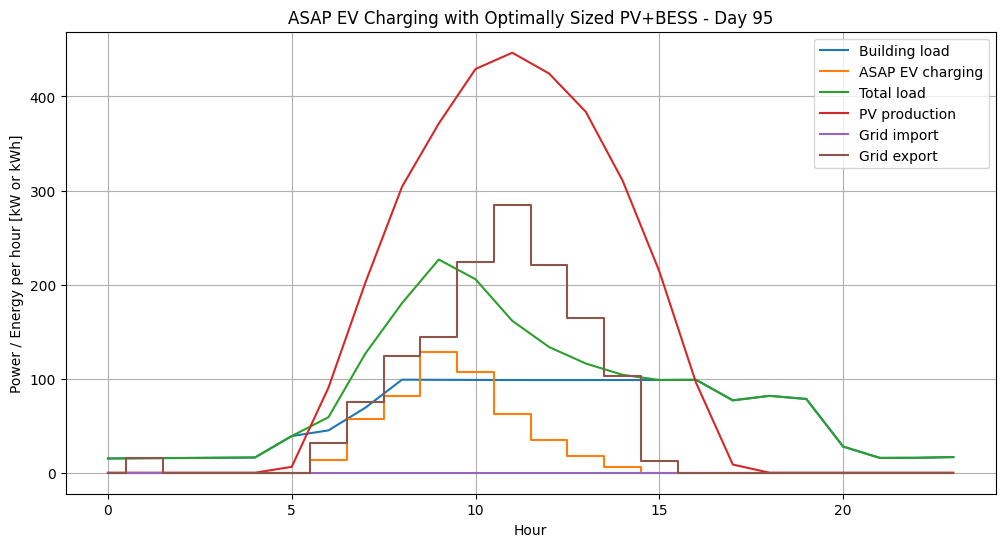

In [9]:
# ==========================================================
# Plot ASAP case operation
# ==========================================================

hours = np.arange(24)

plt.figure(figsize=(12,6))

plt.plot(hours, asap_result["building_load"], label="Building load")
plt.step(hours, asap_result["ev_profile"], where="mid", label="ASAP EV charging")
plt.plot(hours, asap_result["total_load"], label="Total load")
plt.plot(hours, asap_result["pv_day"], label="PV production")
plt.step(hours, asap_result["grid_import"], where="mid", label="Grid import")
plt.step(hours, asap_result["grid_export"], where="mid", label="Grid export")

plt.xlabel("Hour")
plt.ylabel("Power / Energy per hour [kW or kWh]")
plt.title("ASAP EV Charging with Optimally Sized PV+BESS - Day 95")
plt.grid()
plt.legend()

plt.show()

Flexible EV + PV + BESS Solver 

In [10]:
# ==========================================================
# Function: solve daily PV+BESS operation with flexible EVs
#
# Here EV charging is controllable.
#
# The optimizer chooses:
# - when each EV charges
# - battery charge/discharge
# - grid import/export
#
# while respecting:
# - EV parking windows
# - EV energy requirements
# - BESS constraints
# ==========================================================

def solve_daily_flexible_ev(day_number):

    N = 24
    dt = 1.0

    building_load = load_year[
        (day_number - 1) * 24 : day_number * 24
    ]

    pv_day = S_PV_opt * pv_factor[
        (day_number - 1) * 24 : day_number * 24
    ]

    price_day = price_year[
        (day_number - 1) * 24 : day_number * 24
    ]

    ev_day = ev[
        ev["day"] == day_number
    ].copy()

    ev_opt = ev_day[
        ev_day["energy_kwh"] > 0
    ].copy().reset_index(drop=True)

    n_ev = len(ev_opt)

    # ---------------- variable indexing ----------------

    idx_ev_start = 0
    idx_ch_start = idx_ev_start + n_ev * N
    idx_dch_start = idx_ch_start + N
    idx_soc_start = idx_dch_start + N
    idx_grid_import_start = idx_soc_start + (N + 1)
    idx_grid_export_start = idx_grid_import_start + N

    n_vars = idx_grid_export_start + N

    # ---------------- objective ----------------
    # Minimize grid import cost.
    # Export revenue is ignored for now.

    c = np.zeros(n_vars)

    for h in range(N):
        c[idx_grid_import_start + h] = price_day[h]

    # ---------------- equality constraints ----------------

    A_eq = []
    b_eq = []

    # Power balance
    for h in range(N):

        row = np.zeros(n_vars)

        # EV charging terms
        for i in range(n_ev):
            row[idx_ev_start + i * N + h] = 1.0

        # BESS
        row[idx_ch_start + h] = 1.0
        row[idx_dch_start + h] = -1.0

        # Grid
        row[idx_grid_import_start + h] = -1.0
        row[idx_grid_export_start + h] = 1.0

        A_eq.append(row)
        b_eq.append(pv_day[h] - building_load[h])

    # EV energy constraints
    for i in range(n_ev):

        row = np.zeros(n_vars)

        for h in range(N):
            row[idx_ev_start + i * N + h] = dt

        A_eq.append(row)
        b_eq.append(ev_opt.loc[i, "energy_kwh"])

    # BESS dynamics
    for h in range(N):

        row = np.zeros(n_vars)

        row[idx_soc_start + h + 1] = 1.0
        row[idx_soc_start + h] = -1.0
        row[idx_ch_start + h] = -eta_ch * dt
        row[idx_dch_start + h] = dt / eta_dch

        A_eq.append(row)
        b_eq.append(0.0)

    # Initial SOC
    row = np.zeros(n_vars)
    row[idx_soc_start] = 1.0

    A_eq.append(row)
    b_eq.append(SOC_initial)

    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)

    # ---------------- bounds ----------------

    bounds = []

    # EV charging bounds
    for i in range(n_ev):

        connection_minute = ev_opt.loc[i, "connection_minute"]
        disconnection_minute = ev_opt.loc[i, "disconnection_minute"]

        for h in range(N):

            hour_start = h * 60
            hour_end = (h + 1) * 60

            overlap_min = max(
                0,
                min(disconnection_minute, hour_end)
                - max(connection_minute, hour_start)
            )

            if overlap_min > 0:
                bounds.append((0, 7.0))
            else:
                bounds.append((0, 0))

    # BESS charge
    for h in range(N):
        bounds.append((0, P_BESS_opt))

    # BESS discharge
    for h in range(N):
        bounds.append((0, P_BESS_opt))

    # SOC
    for h in range(N + 1):
        bounds.append((SOC_min, SOC_max))

    # Grid import
    for h in range(N):
        bounds.append((0, None))

    # Grid export
    for h in range(N):
        bounds.append((0, None))

    # ---------------- solve ----------------

    result = linprog(
        c=c,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=bounds,
        method="highs"
    )

    if not result.success:
        return {
            "success": False,
            "message": result.message
        }

    x = result.x

    P_EV = x[
        idx_ev_start : idx_ch_start
    ].reshape(n_ev, N)

    ev_profile = P_EV.sum(axis=0)

    P_ch = x[idx_ch_start : idx_dch_start]
    P_dch = x[idx_dch_start : idx_soc_start]
    SOC = x[idx_soc_start : idx_grid_import_start]
    grid_import = x[idx_grid_import_start : idx_grid_export_start]
    grid_export = x[idx_grid_export_start :]

    return {
        "success": True,
        "cost_EUR": result.fun,
        "building_load": building_load,
        "ev_profile": ev_profile,
        "pv_day": pv_day,
        "P_ch": P_ch,
        "P_dch": P_dch,
        "SOC": SOC,
        "grid_import": grid_import,
        "grid_export": grid_export,
        "price_day": price_day,
        "n_ev": n_ev
    }

In [11]:
# ==========================================================
# Flexible EV case for high-demand day
# ==========================================================

flex_result = solve_daily_flexible_ev(DAY)

print("Success:", flex_result["success"])
print("Flexible case cost [EUR]:", flex_result["cost_EUR"])
print("EV energy [kWh]:", flex_result["ev_profile"].sum())
print("Grid import [kWh]:", flex_result["grid_import"].sum())
print("Grid export [kWh]:", flex_result["grid_export"].sum())
print("Peak EV power [kW]:", flex_result["ev_profile"].max())

Success: True
Flexible case cost [EUR]: 0.0
EV energy [kWh]: 509.0
Grid import [kWh]: 0.0
Grid export [kWh]: 1372.0088910477184
Peak EV power [kW]: 175.0


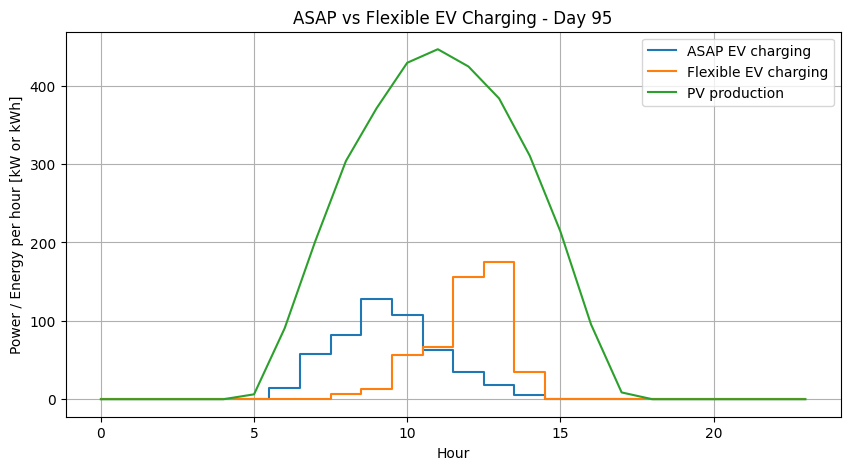

In [12]:
# ==========================================================
# Compare ASAP and flexible EV charging profiles
# ==========================================================

hours = np.arange(24)

plt.figure(figsize=(10,5))

plt.step(hours, asap_result["ev_profile"], where="mid", label="ASAP EV charging")
plt.step(hours, flex_result["ev_profile"], where="mid", label="Flexible EV charging")
plt.plot(hours, flex_result["pv_day"], label="PV production")

plt.xlabel("Hour")
plt.ylabel("Power / Energy per hour [kW or kWh]")
plt.title("ASAP vs Flexible EV Charging - Day 95")
plt.grid()
plt.legend()

plt.show()

Running all the Scenario 

In [13]:
# ==========================================================
# Compare ASAP vs Flexible charging
# for Low, Medium and High EV demand days
# ==========================================================

comparison_results = []

for scenario_name, day_number in scenario_days.items():

    print(f"\nRunning scenario: {scenario_name} (Day {day_number})")

    # ------------------------------------
    # Build ASAP profile
    # ------------------------------------

    ev_day = ev[
        ev["day"] == day_number
    ].copy()

    ev_asap = build_asap_profile(
        ev_day,
        P_EV_max=7.0
    )

    # ------------------------------------
    # Solve ASAP case
    # ------------------------------------

    asap_result = solve_daily_fixed_ev(
        day_number,
        ev_asap
    )

    # ------------------------------------
    # Solve flexible case
    # ------------------------------------

    flex_result = solve_daily_flexible_ev(
        day_number
    )

    comparison_results.append({

        "Scenario": scenario_name,
        "Day": day_number,

        "ASAP_cost_EUR":
            asap_result["cost_EUR"],

        "Flexible_cost_EUR":
            flex_result["cost_EUR"],

        "Cost_saving_EUR":
            asap_result["cost_EUR"]
            - flex_result["cost_EUR"],

        "ASAP_grid_import":
            asap_result["grid_import"].sum(),

        "Flexible_grid_import":
            flex_result["grid_import"].sum(),

        "ASAP_grid_export":
            asap_result["grid_export"].sum(),

        "Flexible_grid_export":
            flex_result["grid_export"].sum(),

        "ASAP_peak_EV":
            asap_result["ev_profile"].max(),

        "Flexible_peak_EV":
            flex_result["ev_profile"].max(),

        "EV_energy":
            flex_result["ev_profile"].sum()
    })

comparison_df = pd.DataFrame(
    comparison_results
)

comparison_df


Running scenario: Low (Day 106)

Running scenario: Medium (Day 20)

Running scenario: High (Day 95)


,Scenario,Day,ASAP_cost_EUR,Flexible_cost_EUR,Cost_saving_EUR,ASAP_grid_import,Flexible_grid_import,ASAP_grid_export,Flexible_grid_export,ASAP_peak_EV,Flexible_peak_EV,EV_energy
0,Low,106,0.00000,0.000000,0.000000,0.000000,0.000000,1677.319903,1677.319903,11.8,21.0,37.0
1,Medium,20,94.21768,92.617732,1.599948,1296.263305,1296.263305,0.000000,0.000000,68.5,132.0,303.0
2,High,95,0.00000,0.000000,0.000000,0.000000,0.000000,1400.274606,1372.008891,127.9,175.0,509.0


In [14]:
# ==========================================================
# Summary table
# ==========================================================

comparison_df.round(2)

,Scenario,Day,ASAP_cost_EUR,Flexible_cost_EUR,Cost_saving_EUR,ASAP_grid_import,Flexible_grid_import,ASAP_grid_export,Flexible_grid_export,ASAP_peak_EV,Flexible_peak_EV,EV_energy
0,Low,106,0.00,0.00,0.0,0.00,0.00,1677.32,1677.32,11.8,21.0,37.0
1,Medium,20,94.22,92.62,1.6,1296.26,1296.26,0.00,0.00,68.5,132.0,303.0
2,High,95,0.00,0.00,0.0,0.00,0.00,1400.27,1372.01,127.9,175.0,509.0


In [15]:
# ==========================================================
# Save comparison table
# ==========================================================

comparison_df.to_csv(
    "../results/tables/notebook14_EV_comparison.csv",
    index=False
)

print("Results saved.")

Results saved.


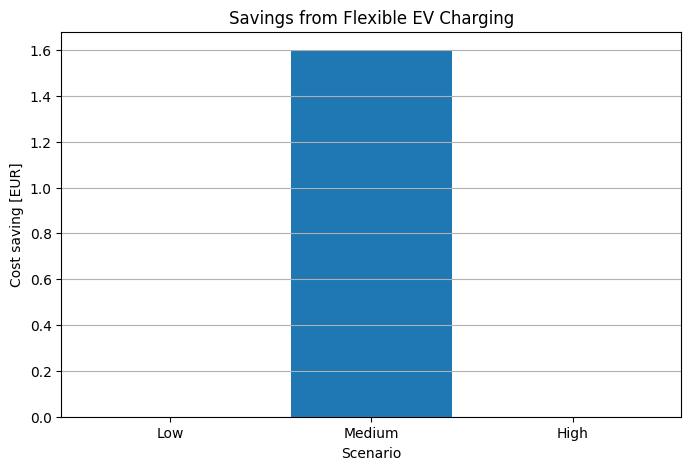

In [16]:
# ==========================================================
# Cost savings from flexible charging
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Scenario"],
    comparison_df["Cost_saving_EUR"]
)

plt.ylabel("Cost saving [EUR]")
plt.xlabel("Scenario")
plt.title("Savings from Flexible EV Charging")

plt.grid(axis="y")

plt.show()

## OSOPSS Day-Ahead Scheduling with ASAP EV Load

In [17]:
# ==========================================================
# OSOPSS-style day-ahead PV+BESS scheduling
# with fixed load input
#
# This function can solve:
# 1) Building load only
# 2) Building load + ASAP EV load
#
# This follows the course idea:
# EV ASAP charging is added as non-controllable demand.
# ==========================================================

def solve_osopss_daily_fixed_load(day_number, extra_load=None):

    N = 24
    dt = 1.0

    if extra_load is None:
        extra_load = np.zeros(N)

    load_day = load_year[(day_number - 1) * 24 : day_number * 24]
    total_load = load_day + extra_load

    pv_day = S_PV_opt * pv_factor[(day_number - 1) * 24 : day_number * 24]
    price_day = price_year[(day_number - 1) * 24 : day_number * 24]

    # Import/export prices, like OSOPSS logic
    p_E_plus = 1.1 * price_day + 0.05
    p_E_minus = 0.9 * price_day - 0.01

    p_pp = 4.0 / 30.0   # daily equivalent of monthly peak price

    # Variables:
    # P_ch, P_dch, SOC, grid_import, grid_export, peak
    idx_ch = 0
    idx_dch = idx_ch + N
    idx_soc = idx_dch + N
    idx_imp = idx_soc + N + 1
    idx_exp = idx_imp + N
    idx_peak = idx_exp + N

    n_vars = idx_peak + 1

    c = np.zeros(n_vars)

    for h in range(N):
        c[idx_imp + h] = p_E_plus[h]
        c[idx_exp + h] = -p_E_minus[h]

    c[idx_peak] = p_pp

    A_eq = []
    b_eq = []

    # Power balance
    for h in range(N):
        row = np.zeros(n_vars)

        row[idx_ch + h] = 1
        row[idx_dch + h] = -1
        row[idx_imp + h] = -1
        row[idx_exp + h] = 1

        A_eq.append(row)
        b_eq.append(pv_day[h] - total_load[h])

    # SOC dynamics
    for h in range(N):
        row = np.zeros(n_vars)

        row[idx_soc + h + 1] = 1
        row[idx_soc + h] = -1
        row[idx_ch + h] = -eta_ch * dt
        row[idx_dch + h] = dt / eta_dch

        A_eq.append(row)
        b_eq.append(0)

    # Initial SOC
    row = np.zeros(n_vars)
    row[idx_soc] = 1
    A_eq.append(row)
    b_eq.append(SOC_initial)

    # Terminal SOC = initial SOC
    row = np.zeros(n_vars)
    row[idx_soc + N] = 1
    A_eq.append(row)
    b_eq.append(SOC_initial)

    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)

    A_ub = []
    b_ub = []

    # Peak constraint: grid_import[h] <= peak
    for h in range(N):
        row = np.zeros(n_vars)
        row[idx_imp + h] = 1
        row[idx_peak] = -1

        A_ub.append(row)
        b_ub.append(0)

    A_ub = np.array(A_ub)
    b_ub = np.array(b_ub)

    bounds = []

    for h in range(N):
        bounds.append((0, P_BESS_opt))      # charge

    for h in range(N):
        bounds.append((0, P_BESS_opt))      # discharge

    for h in range(N + 1):
        bounds.append((SOC_min, SOC_max))   # SOC

    for h in range(N):
        bounds.append((0, None))            # import

    for h in range(N):
        bounds.append((0, None))            # export

    bounds.append((0, None))                # peak

    result = linprog(
        c=c,
        A_eq=A_eq,
        b_eq=b_eq,
        A_ub=A_ub,
        b_ub=b_ub,
        bounds=bounds,
        method="highs"
    )

    if not result.success:
        return {"success": False, "message": result.message}

    x = result.x

    return {
        "success": True,
        "cost_EUR": result.fun,
        "load_day": load_day,
        "extra_load": extra_load,
        "total_load": total_load,
        "pv_day": pv_day,
        "P_ch": x[idx_ch:idx_dch],
        "P_dch": x[idx_dch:idx_soc],
        "SOC": x[idx_soc:idx_imp],
        "grid_import": x[idx_imp:idx_exp],
        "grid_export": x[idx_exp:idx_peak],
        "peak_grid_import": x[idx_peak],
        "price_day": price_day
    }

In [18]:
DAY = 95

ev_day = ev[ev["day"] == DAY].copy()
ev_asap = build_asap_profile(ev_day)

result_no_ev = solve_osopss_daily_fixed_load(DAY)
result_with_ev = solve_osopss_daily_fixed_load(DAY, ev_asap)

print("No EV cost:", result_no_ev["cost_EUR"])
print("With ASAP EV cost:", result_with_ev["cost_EUR"])

print("No EV grid import:", result_no_ev["grid_import"].sum())
print("With EV grid import:", result_with_ev["grid_import"].sum())

print("No EV peak:", result_no_ev["peak_grid_import"])
print("With EV peak:", result_with_ev["peak_grid_import"])

No EV cost: -59.341818794539165
With ASAP EV cost: -37.21664664453916
No EV grid import: 128.9117858243536
With EV grid import: 128.9117858243536
No EV peak: 20.946896083475597
With EV peak: 20.946896083475597


In [19]:
# ==========================================================
# Difference caused by adding ASAP EV charging
# ==========================================================

delta_cost = result_with_ev["cost_EUR"] - result_no_ev["cost_EUR"]
delta_import = result_with_ev["grid_import"].sum() - result_no_ev["grid_import"].sum()
delta_export = result_with_ev["grid_export"].sum() - result_no_ev["grid_export"].sum()
delta_peak = result_with_ev["peak_grid_import"] - result_no_ev["peak_grid_import"]

print("Cost increase due to EV [EUR]:", delta_cost)
print("Grid import increase [kWh]:", delta_import)
print("Grid export change [kWh]:", delta_export)
print("Peak grid import increase [kW]:", delta_peak)

Cost increase due to EV [EUR]: 22.125172150000004
Grid import increase [kWh]: 0.0
Grid export change [kWh]: -509.0
Peak grid import increase [kW]: 0.0


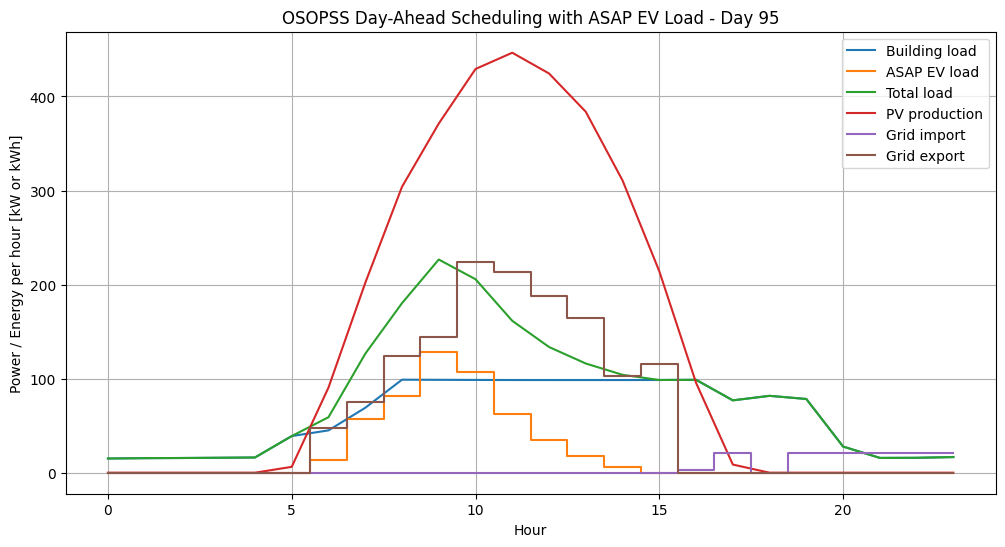

In [ ]:
hours = np.arange(24)

plt.figure(figsize=(12,6))

plt.plot(hours, result_with_ev["load_day"], label="Building load")
plt.step(hours, result_with_ev["extra_load"], where="mid", label="ASAP EV load")
plt.plot(hours, result_with_ev["total_load"], label="Total load")
plt.plot(hours, result_with_ev["pv_day"], label="PV production")
plt.step(hours, result_with_ev["grid_import"], where="mid", label="Grid import")
plt.step(hours, result_with_ev["grid_export"], where="mid", label="Grid export")

plt.xlabel("Hour")
plt.ylabel("Power / Energy per hour [kW or kWh]")
plt.title("OSOPSS Day-Ahead Scheduling with ASAP EV Load - Day 95")
plt.grid()
plt.legend()
plt.show()
# highest PV production.

In [21]:
# ==========================================================
# OSOPSS fixed-load comparison:
# Building only vs Building + ASAP EV load
# ==========================================================

osopss_comparison_results = []

for scenario_name, day_number in scenario_days.items():

    print(f"Running {scenario_name} scenario - Day {day_number}")

    # ------------------------------------------------------
    # Build ASAP EV profile for this day
    # ------------------------------------------------------

    ev_day = ev[
        ev["day"] == day_number
    ].copy()

    ev_asap = build_asap_profile(
        ev_day,
        P_EV_max=7.0
    )

    # ------------------------------------------------------
    # Case A: Building load only
    # ------------------------------------------------------

    result_no_ev = solve_osopss_daily_fixed_load(
        day_number
    )

    # ------------------------------------------------------
    # Case B: Building load + ASAP EV charging
    # ------------------------------------------------------

    result_with_ev = solve_osopss_daily_fixed_load(
        day_number,
        extra_load=ev_asap
    )

    # ------------------------------------------------------
    # Store comparison metrics
    # ------------------------------------------------------

    osopss_comparison_results.append({

        "Scenario": scenario_name,
        "Day": day_number,

        "EV_energy_kWh":
            ev_asap.sum(),

        "No_EV_cost_EUR":
            result_no_ev["cost_EUR"],

        "With_EV_cost_EUR":
            result_with_ev["cost_EUR"],

        "Cost_increase_EUR":
            result_with_ev["cost_EUR"]
            - result_no_ev["cost_EUR"],

        "No_EV_grid_import_kWh":
            result_no_ev["grid_import"].sum(),

        "With_EV_grid_import_kWh":
            result_with_ev["grid_import"].sum(),

        "Grid_import_increase_kWh":
            result_with_ev["grid_import"].sum()
            - result_no_ev["grid_import"].sum(),

        "No_EV_grid_export_kWh":
            result_no_ev["grid_export"].sum(),

        "With_EV_grid_export_kWh":
            result_with_ev["grid_export"].sum(),

        "Grid_export_change_kWh":
            result_with_ev["grid_export"].sum()
            - result_no_ev["grid_export"].sum(),

        "No_EV_peak_grid_kW":
            result_no_ev["peak_grid_import"],

        "With_EV_peak_grid_kW":
            result_with_ev["peak_grid_import"],

        "Peak_increase_kW":
            result_with_ev["peak_grid_import"]
            - result_no_ev["peak_grid_import"]
    })

osopss_comparison_df = pd.DataFrame(
    osopss_comparison_results
)

osopss_comparison_df.round(2)

Running Low scenario - Day 106
Running Medium scenario - Day 20
Running High scenario - Day 95


,Scenario,Day,EV_energy_kWh,No_EV_cost_EUR,With_EV_cost_EUR,Cost_increase_EUR,No_EV_grid_import_kWh,With_EV_grid_import_kWh,Grid_import_increase_kWh,No_EV_grid_export_kWh,With_EV_grid_export_kWh,Grid_export_change_kWh,No_EV_peak_grid_kW,With_EV_peak_grid_kW,Peak_increase_kW
0,Low,106,37.0,-70.45,-67.84,2.61,155.54,155.54,0.00,1762.48,1725.48,-37.0,15.61,15.61,0.00
1,Medium,20,303.0,157.46,200.09,42.63,1130.53,1438.63,308.11,0.00,0.00,0.0,61.75,73.76,12.01
2,High,95,509.0,-59.34,-37.22,22.13,128.91,128.91,0.00,1908.11,1399.11,-509.0,20.95,20.95,0.00


In [22]:
# ==========================================================
# Save OSOPSS fixed-load comparison table
# ==========================================================

osopss_comparison_df.to_csv(
    "../results/tables/notebook14_OSOPSS_ASAP_fixed_load_comparison.csv",
    index=False
)

print("OSOPSS ASAP fixed-load comparison saved.")

OSOPSS ASAP fixed-load comparison saved.


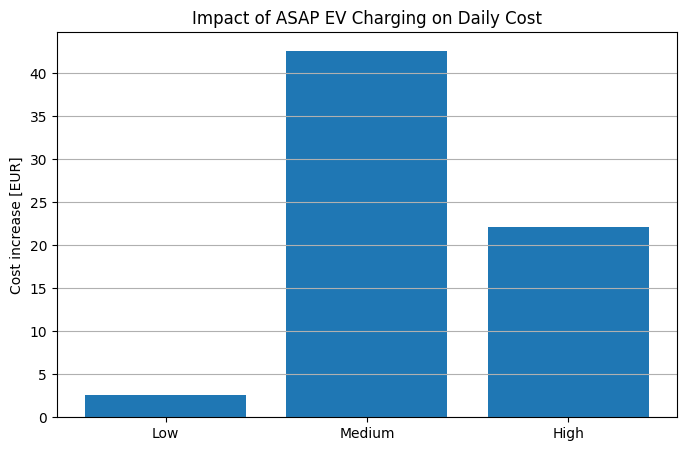

In [23]:
plt.figure(figsize=(8,5))

plt.bar(
    osopss_comparison_df["Scenario"],
    osopss_comparison_df["Cost_increase_EUR"]
)

plt.ylabel("Cost increase [EUR]")
plt.title("Impact of ASAP EV Charging on Daily Cost")

plt.grid(axis="y")
plt.show()

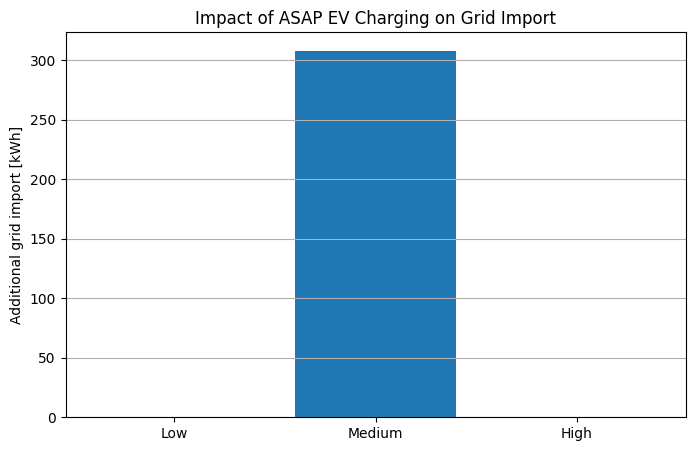

In [24]:
plt.figure(figsize=(8,5))

plt.bar(
    osopss_comparison_df["Scenario"],
    osopss_comparison_df["Grid_import_increase_kWh"]
)

plt.ylabel("Additional grid import [kWh]")
plt.title("Impact of ASAP EV Charging on Grid Import")

plt.grid(axis="y")
plt.show()

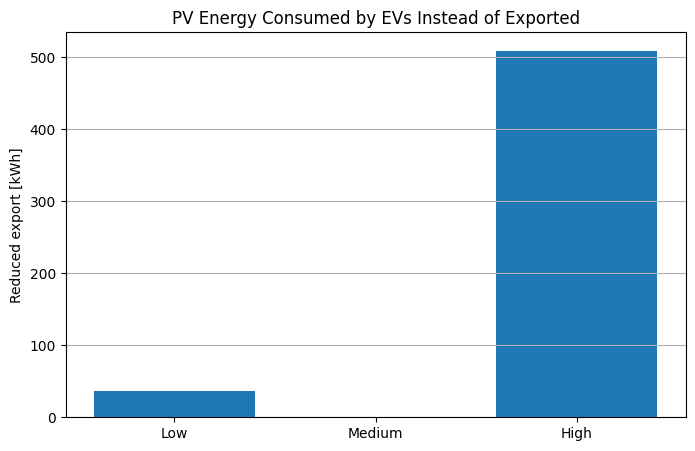

In [25]:
plt.figure(figsize=(8,5))

plt.bar(
    osopss_comparison_df["Scenario"],
    -osopss_comparison_df["Grid_export_change_kWh"]
)

plt.ylabel("Reduced export [kWh]")
plt.title("PV Energy Consumed by EVs Instead of Exported")

plt.grid(axis="y")
plt.show()

In [28]:
print("please consult the text file to check the corresponding information about the code.")

please consult the text file to check the corresponding information about the code.
